# Notebook 1 — The PyMC workflow, on the simplest model there is

**What you will practise here:** the six steps you repeat in *every* PyMC job.

1. Make some fake data where you already know the right answer.
2. Write down the model.
3. Check your priors before you look at the data.
4. Run the sampler.
5. Check whether the sampler worked (this is the ArviZ part).
6. Check whether the model fits the data.

**The example:** we flip a bent coin. We want to find `p`, the chance it lands heads.
That is it. One unknown number. Everything you learn here carries over to models
with 20 unknowns.

**Words you will see (plain meanings):**

- **Prior** - what you believe about a parameter *before* looking at the data.
- **Posterior** - what you believe *after* looking at the data. This is the answer.
- **Likelihood** - the part of the model that says how the data is generated from the parameters.
- **Sampler / MCMC** - a program that draws thousands of plausible parameter values from the posterior.
  You never get one number, you get a cloud of numbers.
- **Draw** - one sample from that cloud.
- **Chain** - one independent run of the sampler. We run several and check they agree.

In [1]:
%pip install pymc
%pip install arviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

print("pymc  ", pm.__version__)
print("arviz ", az.__version__)

# ArviZ changed some function names between version 0.x and 1.x.
# This one line means the rest of the notebook works on either version.
AZ_MAJOR = int(az.__version__.split(".")[0])
plot_ppc = getattr(az, "plot_ppc", None) or az.plot_ppc_dist

pymc   6.3.2
arviz  1.3.0


## Step 1 — Fake data with a known answer

This is the single most useful habit in this whole field: **test on data where you
already know the truth.** If your code cannot recover a number you picked yourself,
it will not recover anything from real data either.

Here the true chance of heads is 0.7. The model is not told this.

In [3]:
rng = np.random.default_rng(42)

TRUE_P = 0.7
N_FLIPS = 50

flips = rng.binomial(1, TRUE_P, size=N_FLIPS)   # array of 0s and 1s

print("flips:", flips)
print(f"heads: {flips.sum()} out of {N_FLIPS}")
print(f"plain average: {flips.mean():.3f}   (true value: {TRUE_P})")

flips: [0 1 0 1 1 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 0 0 1 0 0 1 1 1 1]
heads: 32 out of 50
plain average: 0.640   (true value: 0.7)


## Step 2 — Write the model

Read the model block out loud. It says:

> `p` is somewhere between 0 and 1, and before seeing data I mildly believe it is near 0.5.
> Each flip is a coin toss with that chance `p`. Here are the flips I actually saw.

`pm.Beta(...)` is the prior. A Beta with `alpha=2, beta=2` is a gentle hump centred on 0.5 —
it says "probably not 0 and probably not 1, but I am not fussy".

`observed=flips` is the bit that turns a random variable into data. That one keyword is
the difference between "this is unknown" and "this is measured".

In [4]:
with pm.Model() as coin_model:
    p = pm.Beta("p", alpha=2, beta=2)                 # prior
    obs = pm.Bernoulli("flip", p=p, observed=flips)   # likelihood + data

# A picture of the model. Needs graphviz installed; skip it if it errors.
try:
    display(pm.model_to_graphviz(coin_model))
except Exception as e:
    print("graphviz not installed, skipping picture:", e)

graphviz not installed, skipping picture: This function requires the python library graphviz, along with binaries. The easiest way to install all of this is by running

	conda install -c conda-forge python-graphviz


In [5]:
conda install -c conda-forge python-graphviz

Retrieving notices: done

EnvironmentNotWritableError: The current user does not have write permissions to the target environment.
  environment location: /ROIHU_TYKKY_0W8ewzV/miniforge/envs/env1
  uid: 10037126
  gid: 10037126



Note: you may need to restart the kernel to use updated packages.


## Step 3 — Prior predictive check (do this BEFORE sampling)

A **prior predictive check** means: ignore the real data, and ask the model to invent
fake datasets using only the prior. Then ask *"do these fake datasets look possible?"*

If your priors are silly, the fake data will be silly, and you find out in 2 seconds
instead of after a 10-hour sampling run. This is cheap and it saves people a lot of pain.

Sampling: [flip, p]


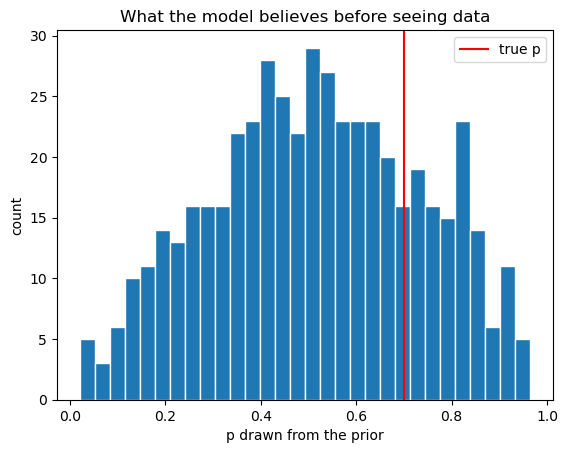

prior covers 0 to 1, humped near 0.5 — sensible for a coin.


In [6]:
with coin_model:
    prior = pm.sample_prior_predictive(500, random_seed=1)

prior_p = np.asarray(prior.prior["p"]).ravel()

plt.hist(prior_p, bins=30, edgecolor="white")
plt.axvline(TRUE_P, color="red", label="true p")
plt.xlabel("p drawn from the prior")
plt.ylabel("count")
plt.title("What the model believes before seeing data")
plt.legend()
plt.show() 

print("prior covers 0 to 1, humped near 0.5 — sensible for a coin.")


## Step 4 — Run the sampler

`pm.sample()` runs **NUTS**. NUTS is a sampler that uses the *slope* (gradient) of the
model to decide where to step next, instead of guessing randomly. That is why it needs
far fewer steps than older methods.

The two numbers that matter:

- `tune=1000` — warm-up steps. The sampler is teaching itself how big a step to take.
  These draws are **thrown away**.
- `draws=2000` — the draws you actually keep.

`chains=4` runs four independent samplers. If they all land in the same place, that is
evidence the answer is real. If they disagree, something is wrong.

> **Note on `cores`:** I set `cores=1` so it runs anywhere. If parallel chains work on
> your machine, `cores=4` is much faster.

In [7]:
with coin_model:
    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=2,
    )

idata

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 2000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           p        (chain, draw) float64 64kB 0.6415 0.6151 0.6409 ... 0.5727 0.6051
│       Attributes:
│           created_at:                 2026-09-10T12:13:32.969944+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.1096458435058594
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 2000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables: (12/18)
│           smallest_eigval        (chain, draw) float64 64kB nan nan nan ... nan nan
│           tree_depth             (chain, draw) int64 64kB 2 2 2 2 2 1 ... 1 2 2 1 1 1
│           divergences            (chain, draw) int64 64kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           reached_max_treedepth  (chain, draw) bool 8kB False False ... False False
│           n_steps                (chain, draw) float64 64kB 3.0 3.0 3.0 ... 1.0 1.0
│           energy_error           (chain, draw) float64 64kB 0.02645 ... -0.1466
│           ...                     ...
│           max_energy_error       (chain, draw) float64 64kB 1.953 0.5584 ... -0.1466
│           perf_counter_start     (chain, draw) float64 64kB 6.897e+05 ... 6.897e+05
│           lp                     (chain, draw) float64 64kB -33.82 -33.83 ... -33.87
│           process_time_diff      (chain, draw) float64 64kB 6.55e-05 ... 2.898e-05
│           step_size              (chain, draw) float64 64kB 1.602 1.602 ... 1.236
│           energy                 (chain, draw) float64 64kB 35.82 34.42 ... 34.05
│       Attributes:
│           created_at:                 2026-09-10T12:13:32.979837+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.3.2
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              1.1096458435058594
│           tuning_steps:               1000
└── Group: /observed_data
        Dimensions:     (flip_dim_0: 50)
        Coordinates:
          * flip_dim_0  (flip_dim_0) int64 400B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49
        Data variables:
            flip        (flip_dim_0) int64 400B 0 1 0 1 1 0 0 0 1 ... 0 0 1 0 0 1 1 1 1
        Attributes:
            created_at:                 2026-09-10T12:13:32.983378+00:00
            creation_library:           ArviZ
            creation_library_version:   1.3.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.3.2
            sample_dims:                []

### What is `idata`?

It is an **InferenceData** object — a labelled container holding everything from the run.
Think of it as a folder with sections:

- `posterior` — the kept draws, shaped `(chain, draw)` per parameter
- `sample_stats` — the sampler's own diary: step sizes, energy, divergences
- `observed_data` — the data you fed in

You pull things out by name.

In [8]:
# 'groups' is a method in ArviZ 0.x and a property in ArviZ 1.x, so handle both
groups = idata.groups() if callable(getattr(idata, "groups", None)) else list(idata.children)
print("what is inside idata:", list(groups))
print()
print("shape of p draws (chain, draw):", idata.posterior["p"].shape)

p_draws = np.asarray(idata.posterior["p"]).ravel()   # flatten all chains together
print("total draws:", p_draws.size)
print(f"posterior mean of p: {p_draws.mean():.3f}    (true value {TRUE_P})")

what is inside idata: ['posterior', 'sample_stats', 'observed_data']

shape of p draws (chain, draw): (4, 2000)
total draws: 8000
posterior mean of p: 0.630    (true value 0.7)


## Step 5 — Did the sampler work? (the ArviZ part)

`az.summary()` is the table you look at first, every single time.

**How to read the columns:**

| column | plain meaning |
|---|---|
| `mean` | average of the draws — your best single guess |
| `sd` | spread of the draws — your uncertainty |
| `hdi_3%` / `hdi_97%` (ArviZ 0.x) or `eti89_lb` / `eti89_ub` (ArviZ 1.x) | an interval the parameter probably sits in |
| `ess_bulk` | **effective sample size.** Draws are correlated, so 8000 draws are not worth 8000 independent ones. This says how many they are *really* worth, for the middle of the distribution. |
| `ess_tail` | same idea, for the edges of the distribution |
| `r_hat` | **do the chains agree?** 1.00 means yes. Above 1.01 means no — do not trust the numbers. |
| `mcse_mean` | how much of the `mean` is just sampler noise |

**Rules of thumb:** want `r_hat` ≤ 1.01, and `ess_bulk` ≥ 400.

In [9]:
az.summary(idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p,0.63,0.066,0.52,0.73,3458,4827,1.00,0.0011,0.00071


### Careful: the rounding trap

`az.summary` rounds to 2 significant figures by default. That can hide a bad `r_hat`:
`1.0199` gets printed as `1.0`, which looks fine but is not.

In **ArviZ 0.x**, to turn rounding off you must pass the *string* `"none"`.
Passing Python's `None` does nothing — it silently falls back to the default.

In [10]:
# In ArviZ 0.x this is the correct way to see full precision:
try:
    print(az.summary(idata, round_to="none"))
except TypeError:
    # ArviZ 1.x dropped this argument
    print("round_to not available in this ArviZ version")

# A version-proof way to see the real number:
print()
print("r_hat, full precision:", float(az.rhat(idata)["p"]))


       mean        sd  eti89_lb  eti89_ub     ess_bulk     ess_tail     r_hat  \
p  0.630223  0.066004  0.519189  0.732616  3458.824661  4827.919619  1.000319   

   mcse_mean   mcse_sd  
p   0.001124  0.000707  

r_hat, full precision: 1.000319258413513


### Trace plots

`az.plot_trace` gives you two panels per parameter:

- **left** — the shape of the posterior, one line per chain. The lines should sit on top
  of each other.
- **right** — the actual path of the sampler over time. You want a dense noisy band, often
  described as a "fuzzy caterpillar". You do **not** want slow wandering, flat stretches,
  or chains sitting at different heights.

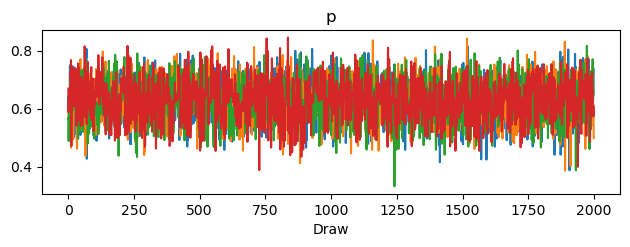

In [11]:
az.plot_trace(idata)
plt.tight_layout()
plt.show()

### Divergences

A **divergence** is the sampler saying "I tried to take a step and the maths blew up here".
Usually it means the posterior has a sharp, narrow region the sampler cannot navigate.

A handful is often harmless. Lots of them means the results are biased and you should not
report them. You will see a model full of divergences in Notebook 3.

In [12]:
n_div = int(idata.sample_stats["diverging"].sum())
n_total = int(np.asarray(idata.sample_stats["diverging"]).size)
print(f"divergences: {n_div} out of {n_total} draws")

divergences: 0 out of 8000 draws


## Step 6 — Posterior predictive check (does the model fit the data?)

Step 5 asked *"did the sampler work?"*. That is a different question from
*"is the model any good?"*. A sampler can converge perfectly on a bad model.

A **posterior predictive check** takes your fitted parameters, generates fake data from
them, and compares that fake data to the real data. If the fake data does not look like
the real data, your model is missing something.

Sampling: [flip]


Output()

/users/nvp/.local/x86_64/lib/python3.12/site-packages/arviz_plots/plots/utils_ppc.py:67: UserWarning: Variables flip in 'observed_data' look binary. For binary outcomes, plot_ppc_pava may be more appropriate.
  warn_if_binary(observed_dist, predictive_dist)
/users/nvp/.local/x86_64/lib/python3.12/site-packages/arviz_plots/plots/utils_ppc.py:67: UserWarning: Variables flip in 'predictive' look binary. For binary outcomes, plot_ppc_pava may be more appropriate.
  warn_if_binary(observed_dist, predictive_dist)
/users/nvp/.local/x86_64/lib/python3.12/site-packages/arviz_plots/plots/utils_ppc.py:69: UserWarning: Variables flip in 'observed' look discrete.
Consider using plot_ppc variants specific for discrete data, such as plot_ppc_pava or plot_ppc_rootogram.
  warn_if_discrete(observed_dist, predictive_dist, kind)
/users/nvp/.local/x86_64/lib/python3.12/site-packages/arviz_plots/plots/utils_ppc.py:69: UserWarning: Variables flip in 'predictive' look discrete.
Consider using plot_ppc varian

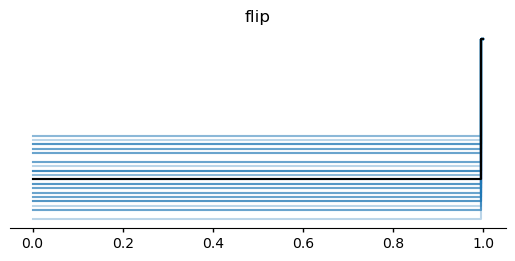

In [13]:
with coin_model:
    pm.sample_posterior_predictive(idata, random_seed=3, extend_inferencedata=True)

plot_ppc(idata)
plt.show()

## Step 7 — Did we get the truth back?

This is the payoff of using fake data. We can score ourselves.

true p            : 0.7
posterior mean    : 0.630
95% interval      : 0.495 to 0.752
truth inside it?  : True


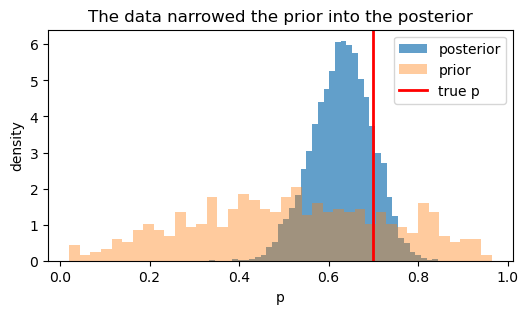

In [15]:
lo, hi = np.percentile(p_draws, [2.5, 97.5])

print(f"true p            : {TRUE_P}")
print(f"posterior mean    : {p_draws.mean():.3f}")
print(f"95% interval      : {lo:.3f} to {hi:.3f}")
print(f"truth inside it?  : {lo < TRUE_P < hi}")

plt.figure(figsize=(6, 3))
plt.hist(p_draws, bins=40, density=True, alpha=.7, label="posterior")
plt.hist(prior_p, bins=40, density=True, alpha=.4, label="prior")
plt.axvline(TRUE_P, color="red", lw=2, label="true p")
plt.xlabel("p"); plt.ylabel("density")
plt.title("The data narrowed the prior into the posterior")
plt.legend()
plt.show()

## Step 8 — More data means a tighter answer

This is the whole point of "how well do observations constrain a parameter".
Run the same model on 20, 200 and 2000 flips and watch the posterior shrink.

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [p]
Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


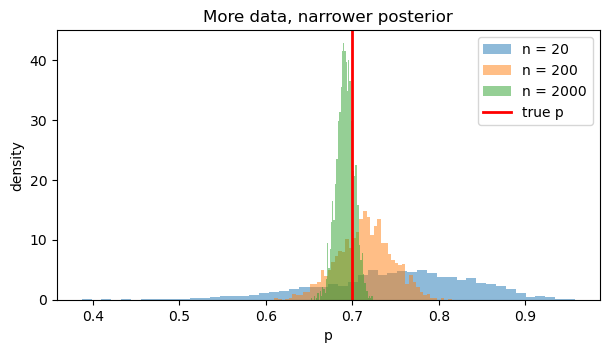

n =    20   sd = 0.0870
n =   200   sd = 0.0316
n =  2000   sd = 0.0102


In [16]:
results = {}

for n in [20, 200, 2000]:
    data_n = rng.binomial(1, TRUE_P, size=n)
    with pm.Model():
        p_n = pm.Beta("p", 2, 2)
        pm.Bernoulli("flip", p=p_n, observed=data_n)
        id_n = pm.sample(1000, tune=1000, chains=2, cores=1,
                         random_seed=4, progressbar=False)
    results[n] = np.asarray(id_n.posterior["p"]).ravel()

plt.figure(figsize=(7, 3.5))
for n, draws in results.items():
    plt.hist(draws, bins=50, density=True, alpha=.5, label=f"n = {n}")
plt.axvline(TRUE_P, color="red", lw=2, label="true p")
plt.xlabel("p"); plt.ylabel("density")
plt.legend(); plt.title("More data, narrower posterior")
plt.show()

for n, draws in results.items():
    print(f"n = {n:5d}   sd = {draws.std():.4f}")